## Exercise 1

**Cell 1:**
In this section, we simulate a simple biological neuron and learn how inputs are multiplied by weights and added to a bias.

In [1]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 1: Grundlagen Neuronaler Netze
# Niveau: Anfänger
# Aufgabe 1 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Simulate a biological neuron: inputs, weights, bias, step activation
import numpy as np

def step_aktivierung(x):
    """Sprungfunktion als einfachste Aktivierungsfunktion"""
    return 1 if x >= 0 else 0

def neuron(eingaben, gewichte, bias):
    """Einfaches Neuron: gewichtete Summe + Bias + Aktivierung"""
    gewichtete_summe = np.dot(eingaben, gewichte) + bias
    ausgabe = step_aktivierung(gewichtete_summe)
    return gewichtete_summe, ausgabe

# Beispiel: Neuron mit 3 Eingaben
eingaben = np.array([0.5, 0.8, 0.3])
gewichte = np.array([0.4, 0.6, -0.2])
bias = -0.1

summe, ausgabe = neuron(eingaben, gewichte, bias)
print(f"Gewichtete Summe: {summe:.4f}")
print(f"Neuronenausgabe: {ausgabe}")
print(f"\nEingaben:  {eingaben}")
print(f"Gewichte:  {gewichte}")
print(f"Bias:      {bias}")


Gewichtete Summe: 0.5200
Neuronenausgabe: 1

Eingaben:  [0.5 0.8 0.3]
Gewichte:  [ 0.4  0.6 -0.2]
Bias:      -0.1


## Exercise 2

**Cell 1:**
Here, a continuous activation function (like Sigmoid) is explored.

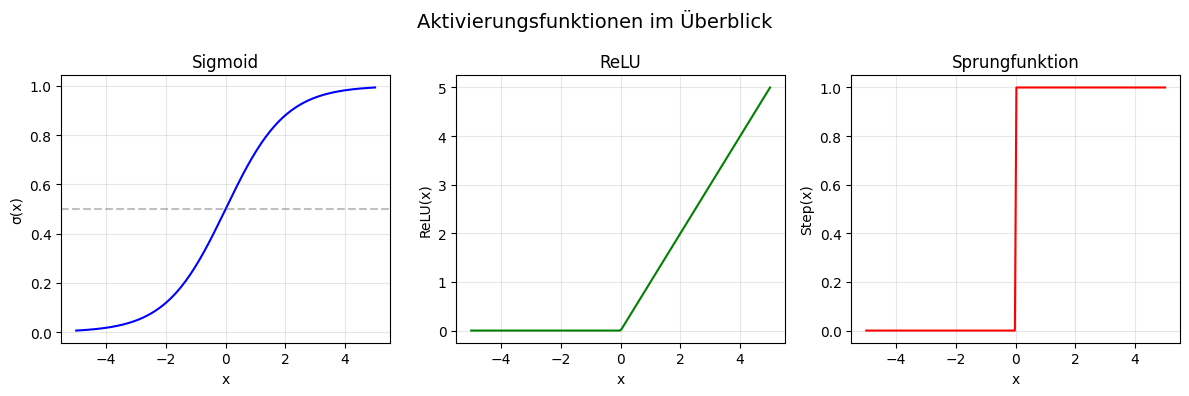

Plot gespeichert: aktivierungsfunktionen.png


In [1]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 1: Grundlagen Neuronaler Netze
# Niveau: Anfänger
# Aufgabe 2 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Visualize Sigmoid, ReLU, and Step activation functions
import numpy as np
import matplotlib

import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 200)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def step(x):
    return np.where(x >= 0, 1, 0)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('Aktivierungsfunktionen im Überblick', fontsize=14)

axes[0].plot(x, sigmoid(x), color='blue')
axes[0].set_title('Sigmoid')
axes[0].set_xlabel('x'); axes[0].set_ylabel('σ(x)')
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, relu(x), color='green')
axes[1].set_title('ReLU')
axes[1].set_xlabel('x'); axes[1].set_ylabel('ReLU(x)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(x, step(x), color='red')
axes[2].set_title('Sprungfunktion')
axes[2].set_xlabel('x'); axes[2].set_ylabel('Step(x)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('aktivierungsfunktionen.png', dpi=100)
plt.show()
print("Plot gespeichert: aktivierungsfunktionen.png")


## Exercise 3

**Cell 1:**
Understanding the concept of Loss calculation for training neural networks.

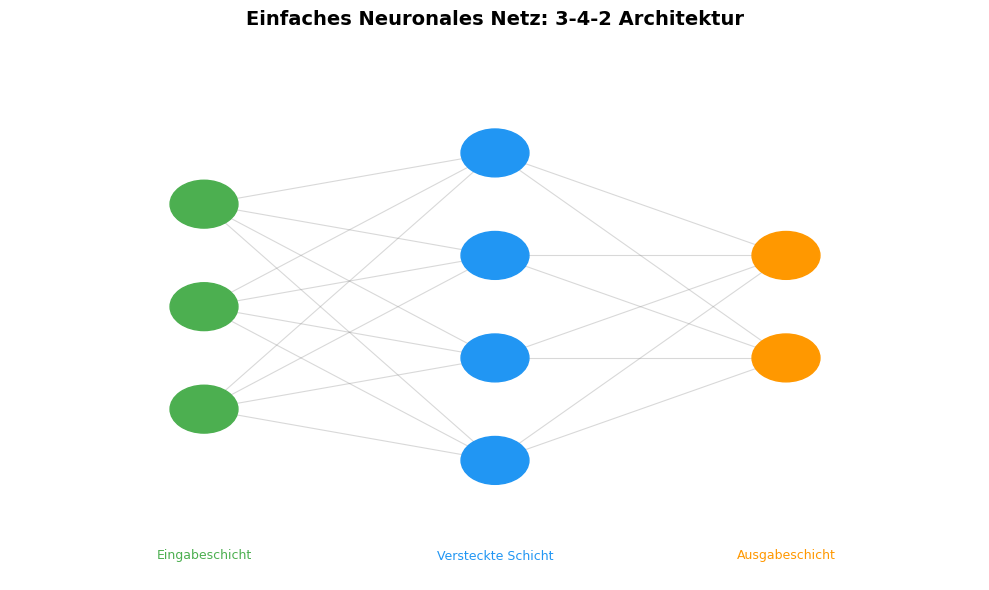

Netzwerk-Diagramm gespeichert: netzwerk_architektur.png
Architektur: 3-4-2 Netz mit 20 Verbindungen


In [1]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 1: Grundlagen Neuronaler Netze
# Niveau: Anfänger
# Aufgabe 3 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Draw a simple neural network architecture diagram
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.set_xlim(0, 10); ax.set_ylim(0, 8)
ax.axis('off')
ax.set_title('Einfaches Neuronales Netz: 3-4-2 Architektur', fontsize=14, fontweight='bold')

# Schichten definieren
schichten = [
    {'x': 2, 'neuronen': 3, 'farbe': '#4CAF50', 'label': 'Eingabeschicht'},
    {'x': 5, 'neuronen': 4, 'farbe': '#2196F3', 'label': 'Versteckte Schicht'},
    {'x': 8, 'neuronen': 2, 'farbe': '#FF9800', 'label': 'Ausgabeschicht'},
]

positionen = []
for schicht in schichten:
    n = schicht['neuronen']
    y_start = (8 - (n-1) * 1.5) / 2
    pos = [(schicht['x'], y_start + i * 1.5) for i in range(n)]
    positionen.append(pos)
    ax.text(schicht['x'], 0.3, schicht['label'], ha='center', fontsize=9, color=schicht['farbe'])
    for (px, py) in pos:
        circle = plt.Circle((px, py), 0.35, color=schicht['farbe'], zorder=3)
        ax.add_patch(circle)

# Verbindungen zeichnen
for i in range(len(positionen)-1):
    for (x1, y1) in positionen[i]:
        for (x2, y2) in positionen[i+1]:
            ax.plot([x1, x2], [y1, y2], 'gray', alpha=0.3, linewidth=0.8, zorder=1)

plt.tight_layout()
plt.savefig('netzwerk_architektur.png', dpi=100)
plt.show()
print("Netzwerk-Diagramm gespeichert: netzwerk_architektur.png")
print(f"Architektur: 3-4-2 Netz mit {3*4 + 4*2} Verbindungen")
